# Analysis for odd responses sqisign

In [300]:
from pathlib import Path
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

In [301]:
p = 62

# Use the newest merged file for this p.
files = sorted(Path('.').glob(f'data/{p}-birandom-merged-*.csv.zip'))
if not files:
    raise FileNotFoundError(f'No merged CSV found for p={p}')
data_file = files[-1]
data_file

PosixPath('data/62-birandom-merged-20260709-102115.csv.zip')

In [302]:
columns = (
    ['I1', 'I2', 'I3', 'I4']
    + ['OL2', 'OL3', 'OL4']
    + ['OR2', 'OR3', 'OR4']
    + [f'inner{i}{j}' for i in range(1, 5) for j in range(1, 5)]
)

df = pd.read_csv(data_file, compression='zip', comment='#', header=None, names=columns)
df

,I1,I2,I3,I4,OL2,OL3,OL4,OR2,OR3,OR4,...,inner23,inner24,inner31,inner32,inner33,inner34,inner41,inner42,inner43,inner44
0,0.199057,0.373286,1.125247,1.166691,0.041085,1.155270,1.432343,0.153889,0.627164,0.680539,...,1,1,0,1,1,1,0,1,1,0
1,0.357934,0.502966,0.558076,1.063522,0.263841,0.273651,0.882299,0.230327,0.426679,0.640375,...,0,1,1,0,1,1,0,1,1,0
2,0.215919,0.410024,0.603909,1.335379,0.382591,0.438924,0.549756,0.264093,0.399542,0.667413,...,0,0,1,0,0,1,0,0,1,0
3,0.186652,0.299044,1.033956,1.202712,0.228714,0.357403,0.812369,0.030545,0.301301,6.885653,...,0,1,0,0,1,1,1,1,1,0
4,0.548765,0.557894,0.654248,0.680699,0.280264,0.462858,0.602370,0.173849,0.440133,0.902464,...,0,1,0,0,1,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132115,0.281463,0.297319,0.916826,1.005816,0.160268,0.587597,0.723861,0.178580,0.449866,0.824249,...,0,0,1,0,0,0,1,0,0,1
132116,0.496825,0.547623,0.612859,0.643620,0.127664,0.226689,2.248476,0.113947,0.256110,2.236113,...,0,0,1,0,0,1,0,0,1,0
132117,0.313496,0.333596,0.653846,0.976881,0.153324,0.508496,0.813367,0.178353,0.348721,1.048258,...,1,0,1,1,0,1,1,0,1,1
132118,0.196949,0.523499,0.567019,1.276337,0.214538,0.221671,1.405477,0.268115,0.347810,0.732079,...,1,1,1,1,0,0,0,1,0,1


In [303]:
total_record = len(df)
total_record

132120

Lets see if it ever happens that all 3 minima and their combinations are all even

In [304]:
print((df['inner11']*df['inner22']*df['inner12']*df['inner23']*df['inner13']*df['inner33']).sum()/total_record)

0.0


In [305]:
print((df['inner11']*df['inner22']*df['inner12']*df['inner23']*df['inner13']).sum()/total_record)

0.01927792915531335


In [306]:
print((df['inner11']*df['inner22']*df['inner12']*df['inner23']*df['inner33']).sum()/total_record)

0.018967605207387224


In [307]:
print((df['inner11']*df['inner22']*df['inner33']).sum()/total_record)

0.13325764456554648


In [308]:
print((df['inner11']*df['inner22']).sum()/total_record)

0.26513775355737207


In [309]:
df[['I1', 'I2', 'I3', 'I4']].corr()

,I1,I2,I3,I4
I1,1.000000,0.055830,-0.490120,-0.363245
I2,0.055830,1.000000,-0.002490,-0.321056
I3,-0.490120,-0.002490,1.000000,0.032581
I4,-0.363245,-0.321056,0.032581,1.000000


In [310]:
df[['inner11', 'inner12', 'inner13', 'inner14',
   'inner21', 'inner22', 'inner23', 'inner24',
   'inner31', 'inner32', 'inner33', 'inner34',
   'inner41', 'inner42', 'inner43', 'inner44']].corr()

,inner11,inner12,inner13,inner14,inner21,inner22,inner23,inner24,inner31,inner32,inner33,inner34,inner41,inner42,inner43,inner44
inner11,1.000000,-0.063039,-0.074585,-0.074231,-0.063039,-0.073144,0.000420,0.004249,-0.074585,0.000420,-0.069782,0.006726,-0.074231,0.004249,0.006726,-0.071302
inner12,-0.063039,1.000000,-0.074442,-0.067975,1.000000,-0.065660,-0.071146,-0.073248,-0.074442,-0.071146,0.004276,0.020172,-0.067975,-0.073248,0.020172,0.001235
inner13,-0.074585,-0.074442,1.000000,-0.071871,-0.074442,0.007806,-0.069984,0.025548,1.000000,-0.069984,-0.072035,-0.069309,-0.071871,0.025548,-0.069309,0.006047
inner14,-0.074231,-0.067975,-0.071871,1.000000,-0.067975,-0.003726,0.023083,-0.070938,-0.071871,0.023083,0.007892,-0.072609,1.000000,-0.070938,-0.072609,-0.072991
inner21,-0.063039,1.000000,-0.074442,-0.067975,1.000000,-0.065660,-0.071146,-0.073248,-0.074442,-0.071146,0.004276,0.020172,-0.067975,-0.073248,0.020172,0.001235
inner22,-0.073144,-0.065660,0.007806,-0.003726,-0.065660,1.000000,-0.073740,-0.071918,0.007806,-0.073740,-0.070244,0.005502,-0.003726,-0.071918,0.005502,-0.071581
inner23,0.000420,-0.071146,-0.069984,0.023083,-0.071146,-0.073740,1.000000,-0.074239,-0.069984,1.000000,-0.074513,-0.071945,0.023083,-0.074239,-0.071945,0.003847
inner24,0.004249,-0.073248,0.025548,-0.070938,-0.073248,-0.071918,-0.074239,1.000000,0.025548,-0.074239,0.001026,-0.067570,-0.070938,1.000000,-0.067570,-0.072114
inner31,-0.074585,-0.074442,1.000000,-0.071871,-0.074442,0.007806,-0.069984,0.025548,1.000000,-0.069984,-0.072035,-0.069309,-0.071871,0.025548,-0.069309,0.006047
inner32,0.000420,-0.071146,-0.069984,0.023083,-0.071146,-0.073740,1.000000,-0.074239,-0.069984,1.000000,-0.074513,-0.071945,0.023083,-0.074239,-0.071945,0.003847


In [311]:
inner_cols = ['inner11', 'inner12', 'inner13', 'inner14',
   'inner21', 'inner22', 'inner23', 'inner24',
   'inner31', 'inner32', 'inner33', 'inner34',
   'inner41', 'inner42', 'inner43', 'inner44']
df["n_nonzero_inner"] = (df[inner_cols] != 0).sum(axis=1)
distribution = df["n_nonzero_inner"].value_counts().sort_index()
print(distribution/total_record)

n_nonzero_inner
4     0.016356
5     0.056812
6     0.086520
7     0.170905
8     0.172691
9     0.207455
10    0.115970
11    0.057819
12    0.077604
13    0.037867
Name: count, dtype: float64


In [312]:
inner_cols = ['inner11', 'inner12', 'inner13', 'inner22', 'inner23', 'inner33']
df["n_nonzero_inner"] = (df[inner_cols] != 0).sum(axis=1)
distribution = df["n_nonzero_inner"].value_counts().sort_index()
print(distribution/total_record)

n_nonzero_inner
1    0.028830
2    0.258152
3    0.314691
4    0.284226
5    0.114101
Name: count, dtype: float64


In [313]:
df[inner_cols].corr()

,inner11,inner12,inner13,inner22,inner23,inner33
inner11,1.000000,-0.063039,-0.074585,-0.073144,0.000420,-0.069782
inner12,-0.063039,1.000000,-0.074442,-0.065660,-0.071146,0.004276
inner13,-0.074585,-0.074442,1.000000,0.007806,-0.069984,-0.072035
inner22,-0.073144,-0.065660,0.007806,1.000000,-0.073740,-0.070244
inner23,0.000420,-0.071146,-0.069984,-0.073740,1.000000,-0.074513
inner33,-0.069782,0.004276,-0.072035,-0.070244,-0.074513,1.000000


<Axes: >

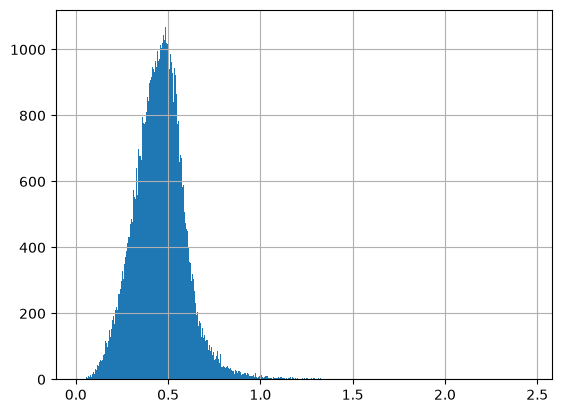

In [314]:
(df['I2']).hist(bins=1000)

<Axes: >

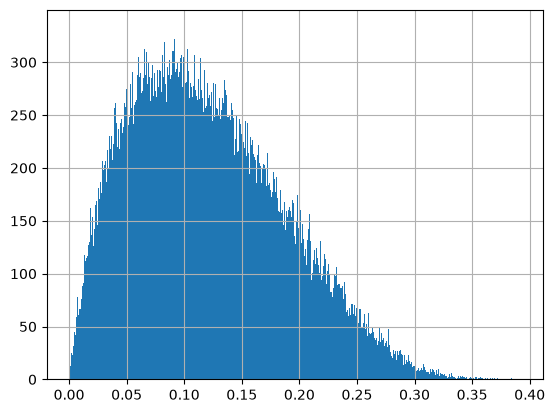

In [315]:
(df['I1']*df['I2']).hist(bins=1000)

In [316]:
df['I12'] = df['I1'] * df['I2']

In [317]:
df[['I12','OR2', 'OR3', 'OR4']].corr()

,I12,OR2,OR3,OR4
I12,1.000000,-0.000237,-0.004809,0.004784
OR2,-0.000237,1.000000,-0.303838,-0.063179
OR3,-0.004809,-0.303838,1.000000,-0.018927
OR4,0.004784,-0.063179,-0.018927,1.000000


In [318]:
dfmin = df[['I1', 'I2', 'I3', 'I4']]
corr = dfmin.corr(method="spearman", numeric_only=True)
corr

,I1,I2,I3,I4
I1,1.000000,0.150534,-0.499140,-0.745838
I2,0.150534,1.000000,0.070413,-0.575551
I3,-0.499140,0.070413,1.000000,0.044018
I4,-0.745838,-0.575551,0.044018,1.000000


In [319]:
df["I3-I1"] = df["I3"] - df["I1"]

## 3rd minima estimates

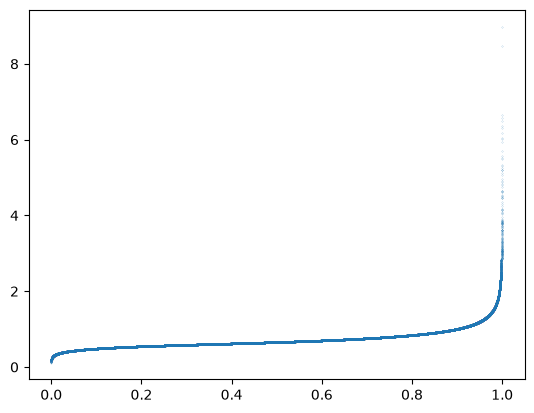

In [328]:
d = (df["I3"]).to_numpy() 

n = len(d)
x = np.sort(d)
plt.scatter(np.arange(n)/n, x, s = 0.01)

# x values from 0 to max(d)
x_vals = np.linspace(0, d.max(), 1000)

# y = number of samples bigger than x
counts = np.array([(d > x).sum() for x in x_vals]) / n

# optional: fit only the tail, e.g. fit_quantile=0.7
threshold = np.quantile(d, 1 - 0.99)

mask = (x_vals > 0) & (counts < 0) & (x_vals <= threshold)



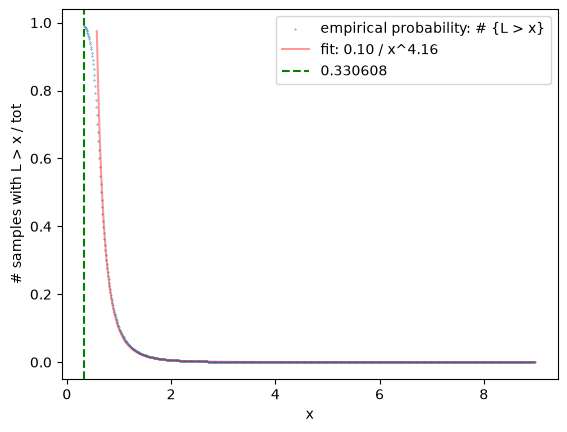

In [329]:
# x values from 0 to max(d)
x_vals = np.linspace(0, d.max(), 1000)

# y = number of samples bigger than x
counts = np.array([(d > x).sum() for x in x_vals]) / n

# optional: fit only the tail, e.g. fit_quantile=0.7
threshold = np.quantile(d, 1 - 0.99)

mask = (x_vals > 0) & (counts > 0) & (x_vals >= threshold)


log_x = np.log(x_vals[mask])
log_y = np.log(counts[mask])

slope, intercept = np.polyfit(log_x, log_y, 1)

a_hat = -slope
C_hat = np.exp(intercept)

fit_y = np.zeros_like(x_vals, dtype=float)

mask_pos = x_vals > 0
fit_y[mask_pos] = C_hat * x_vals[mask_pos] ** (-a_hat)

mask_plot = mask_pos & (fit_y < 1)

plt.scatter(x_vals[mask], counts[mask],
            label="empirical probability: # {L > x}",
            s=0.1)

plt.plot(x_vals[mask_plot], fit_y[mask_plot],
         label=f"fit: {C_hat:.2f} / x^{a_hat:.2f}",
         color="red", alpha = 0.4)

plt.xlabel("x")
plt.ylabel("# samples with L > x / tot")
plt.axvline(x = threshold, color = 'green', linestyle="--", label=f'{threshold:f}')

plt.legend()
plt.show()

## 1st and 2nd minima product estimate

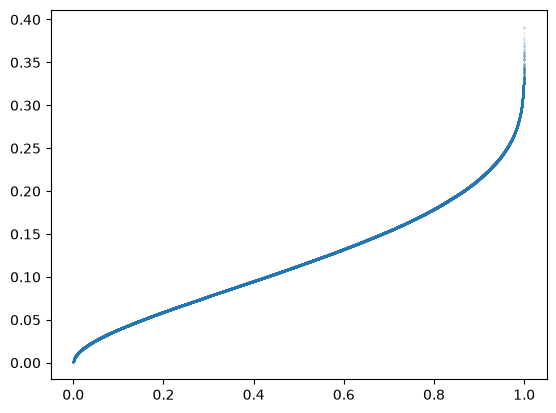

In [330]:
d = (df["I1"]*df["I2"]).to_numpy() 
n = len(d)
x = np.sort(d)
plt.scatter(np.arange(n)/n, x, s = 0.01)

In [333]:
# x values from 0 to max(d)
x_vals = np.linspace(0, d.max(), 1000)

# y = number of samples bigger than x
counts = np.array([(d < x).sum() for x in x_vals]) / n

# optional: only consider vectors shorter than c * p 
# seems, that c = 0.01 start to give results
threshold = 0.1

# the reason for this sieve is that we expect that for shorter vectors the heuristic will better hold
# and we only care about the short case, corresponding to the long tail for lambda_3
mask = (x_vals > 0) & (counts > 0) & (x_vals <= threshold)

# TODO: understand the number theory behind this

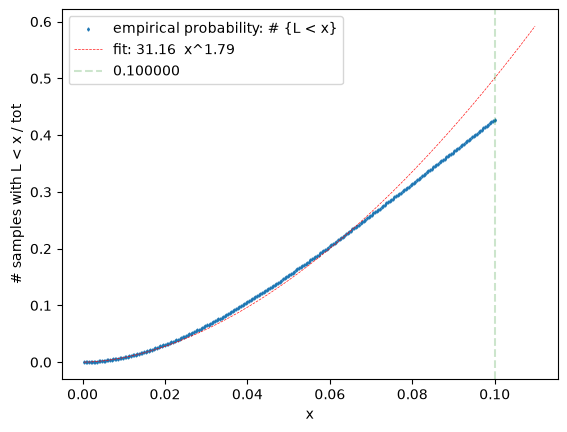

Considering 280 points


In [335]:

log_x = np.log(x_vals[mask])
log_y = np.log(counts[mask])

slope, intercept = np.polyfit(log_x, log_y, 1)

a_hat = slope
C_hat = np.exp(intercept)

fit_y = np.zeros_like(x_vals, dtype=float)

mask_pos = x_vals > 0
fit_y[mask_pos] = C_hat * x_vals[mask_pos] ** (a_hat)

mask_plot = mask_pos & (fit_y < 1) & (x_vals <= threshold*1.1)

plt.scatter(x_vals[mask], counts[mask],
            label="empirical probability: # {L < x}",
            s=2, marker = 'd')

plt.plot(x_vals[mask_plot], fit_y[mask_plot],
         label=f"fit: {C_hat:.2f}  x^{a_hat:.2f}",
         color="red", alpha=0.9, linestyle="--", linewidth=0.5)

plt.xlabel("x")
plt.ylabel("# samples with L < x / tot")
plt.axvline(x = threshold, color = 'green', linestyle="--", label=f'{threshold:f}', alpha=0.2)

plt.legend()
plt.show()

print(f'Considering {sum([ 1 for m in mask_plot if m])} points')

In [16]:
df.describe()

,I1,I2,I3,I4,OL2,OL3,OL4,OR2,OR3,OR4,...,inner23,inner24,inner31,inner32,inner33,inner34,inner41,inner42,inner43,inner44
count,121120.000000,121120.000000,121120.000000,121120.000000,121120.000000,121120.000000,121120.000000,121120.000000,121120.000000,121120.000000,...,121120.000000,121120.000000,121120.000000,121120.000000,121120.000000,121120.000000,121120.000000,121120.000000,121120.000000,121120.000000
mean,0.262799,0.456454,0.719456,1.509584,0.194376,0.495203,1.066281,0.196199,0.465676,1.759294,...,0.532406,0.532571,0.530515,0.532406,0.534049,0.535502,0.533892,0.532571,0.535502,0.536584
std,0.117512,0.143718,0.286950,1.975172,0.107250,0.175087,0.549185,0.102871,0.282452,24.624718,...,0.498951,0.498940,0.499070,0.498951,0.498841,0.498740,0.498852,0.498940,0.498740,0.498662
min,0.001862,0.013268,0.116365,0.528733,0.030987,0.190252,0.489042,0.000133,0.011678,0.404751,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.172409,0.365213,0.566795,0.844443,0.118475,0.368068,0.607113,0.113567,0.335197,0.637247,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.261098,0.454812,0.657058,1.082301,0.205011,0.406916,0.945340,0.191641,0.421954,0.879205,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,0.350080,0.536512,0.794312,1.562725,0.277698,0.560103,1.273252,0.274810,0.519261,1.438507,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,0.624160,2.456409,8.983275,206.441847,0.413080,1.155270,3.761326,0.492326,15.047734,8073.682680,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [12]:
df.iloc[:, :4].quantile([1-1/4**i for i in range(1,10)])

,I1,I2,I3,I4
0.750000,0.350080,0.536512,0.794312,1.562725
0.937500,0.448379,0.658708,1.129371,3.108472
0.984375,0.502580,0.816965,1.600381,6.113044
0.996094,0.536830,1.028281,2.280984,12.234309
0.999023,0.561810,1.323357,3.188625,22.832889
0.999756,0.587124,1.604881,4.626790,43.982202
0.999939,0.602517,1.876560,6.028838,72.422993
0.999985,0.610986,2.047418,6.917371,118.228189
0.999996,0.618400,2.312445,8.745214,170.980791


<Axes: >

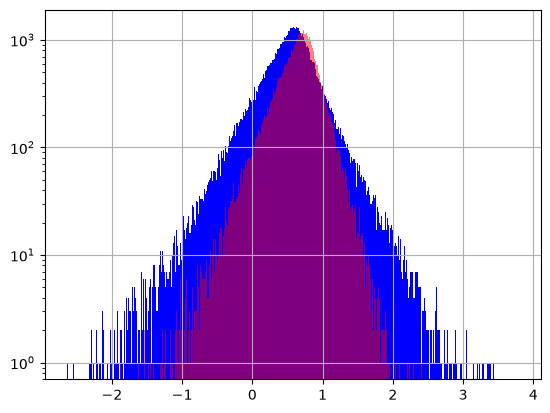

In [59]:
np.log(6*df['I4']*df['I1']).hist(bins=800, log=True, color='blue')
np.log(1.3/df['I3']).hist(bins=800, log=True, alpha=0.5, color='red')

np.float64(0.37213374468177024)

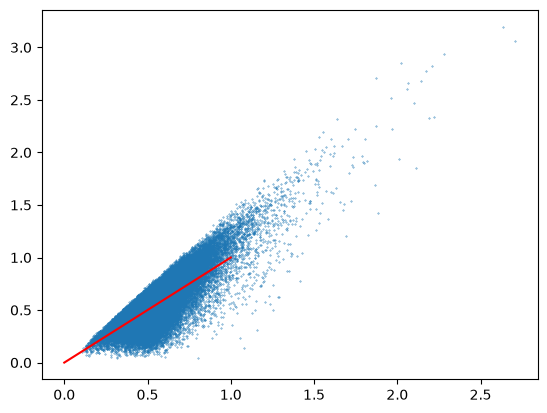

In [64]:
fun1 = np.sqrt(df['I1'] * df['I4'])
m = (fun1 * df['I3']).mean()
plt.scatter(fun1, m/(df['I3']), s=0.1)
plt.plot((0,1), (0,1), 'red')
m

np.float64(0.08967262331255478)

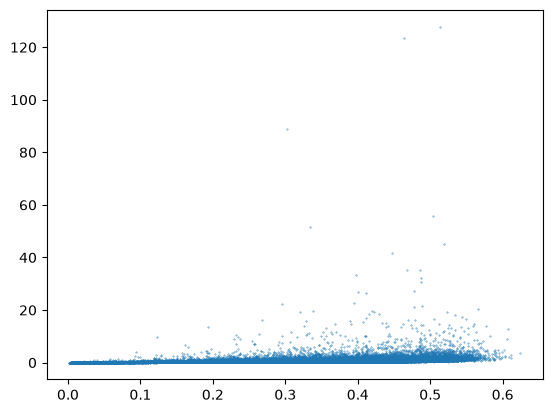

In [43]:
m = (df['I1'] * df['I3-I1']).mean()
plt.scatter(df['I1'], m/df['I3-I1'], s=0.1)
#plt.plot((0,1), (0,1), 'red')
m

np.float64(0.3134985534315788)

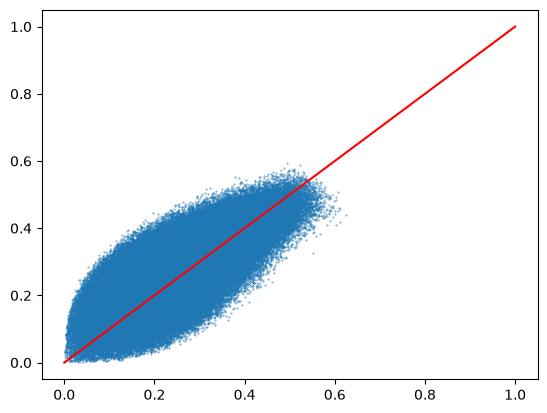

In [24]:
m = (df['I1'] * df['I4']).mean()
plt.scatter(df['I1'], m/df['I4'], s=0.1)
plt.plot((0,1), (0,1), 'red')
m

In [160]:
p = 62

# Use the newest merged file for this p.
files = sorted(Path('.').glob(f'data/{p}-eichler-*.csv'))
if not files:
    raise FileNotFoundError(f'No merged CSV found for p={p}')
data_file = files[-1]
data_file

PosixPath('data/62-eichler-20260708-163832.csv')

# Data with Eichler order minima

In [336]:
columns = (
    ['I1', 'I2', 'I3', 'I4']
    + ['O2', 'O3', 'O4'])

dfe = pd.read_csv(data_file, comment='#', header=None, names=columns)
dfe

,,,,,,,,,,,,,,,,,,,I1,I2,I3,I4,O2,O3,O4
0.199057,0.373286,1.125247,1.166691,0.041085,1.155270,1.432343,0.153889,0.627164,0.680539,1,0,0,0,0,0,1,1,0,1,1,1,0,1,1,0
0.357934,0.502966,0.558076,1.063522,0.263841,0.273651,0.882299,0.230327,0.426679,0.640375,1,1,1,0,1,0,0,1,1,0,1,1,0,1,1,0
0.215919,0.410024,0.603909,1.335379,0.382591,0.438924,0.549756,0.264093,0.399542,0.667413,1,1,1,0,1,0,0,0,1,0,0,1,0,0,1,0
0.186652,0.299044,1.033956,1.202712,0.228714,0.357403,0.812369,0.030545,0.301301,6.885653,0,1,0,1,1,0,0,1,0,0,1,1,1,1,1,0
0.548765,0.557894,0.654248,0.680699,0.280264,0.462858,0.602370,0.173849,0.440133,0.902464,0,1,0,1,1,1,0,1,0,0,1,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0.281463,0.297319,0.916826,1.005816,0.160268,0.587597,0.723861,0.178580,0.449866,0.824249,0,1,1,1,1,1,0,0,1,0,0,0,1,0,0,1
0.496825,0.547623,0.612859,0.643620,0.127664,0.226689,2.248476,0.113947,0.256110,2.236113,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0
0.313496,0.333596,0.653846,0.976881,0.153324,0.508496,0.813367,0.178353,0.348721,1.048258,0,0,1,1,0,0,1,0,1,1,0,1,1,0,1,1
0.196949,0.523499,0.567019,1.276337,0.214538,0.221671,1.405477,0.268115,0.347810,0.732079,1,0,1,0,0,1,1,1,1,1,0,0,0,1,0,1


In [337]:
dfe.corr()

,I1,I2,I3,I4,O2,O3,O4
I1,1.000000,-0.074513,-0.071945,0.023083,-0.074239,-0.071945,0.003847
I2,-0.074513,1.000000,-0.071092,0.007892,0.001026,-0.071092,-0.071691
I3,-0.071945,-0.071092,1.000000,-0.072609,-0.067570,1.000000,-0.066945
I4,0.023083,0.007892,-0.072609,1.000000,-0.070938,-0.072609,-0.072991
O2,-0.074239,0.001026,-0.067570,-0.070938,1.000000,-0.067570,-0.072114
O3,-0.071945,-0.071092,1.000000,-0.072609,-0.067570,1.000000,-0.066945
O4,0.003847,-0.071691,-0.066945,-0.072991,-0.072114,-0.066945,1.000000


In [338]:
dfe['I12'] = dfe['I1'] * dfe['I2']

np.float64(0.1313957008779897)

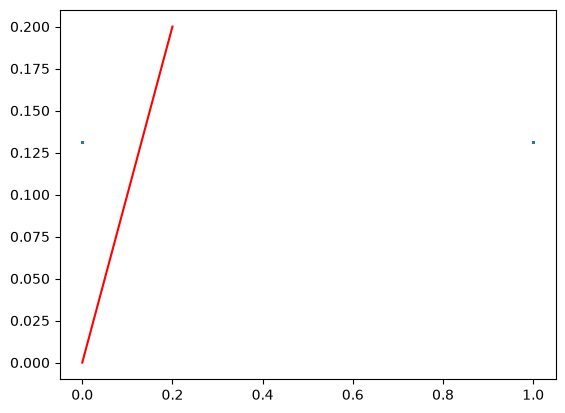

In [339]:
m = (dfe['I12'] * dfe['O2']).mean()
plt.scatter(dfe['I12'], m/dfe['O2'], s=0.1)
plt.plot((0,0.2), (0,0.2), 'red')
m

np.float64(0.08426160801119466)

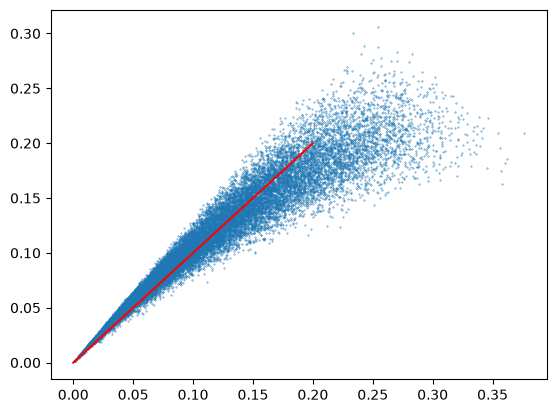

In [179]:
m = (dfe['I12'] * dfe['I3']*dfe['I4']).mean()
plt.scatter(dfe['I12'], m/ (dfe['I3']*dfe['I4']), s=0.1)
plt.plot((0,0.2), (0,0.2), 'red')
m